# EuroSAT baseline classifier

Pipeline sanity-check: train/val split, data loading, training loop, metrics.

Note: EuroSAT gives one label per whole image (classification), not pixel masks. This is *not* the final segmentation model — it just proves the training pipeline works before moving to real Sentinel-2 + ESA WorldCover segmentation data.

In [1]:
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import EuroSAT
from torchvision.models import ResNet18_Weights, resnet18

DATA_DIR = Path.cwd().parent / "data"

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [ ]:
# 1/ Define the data transforms (preprocess to apply to the images when loading the dataset) 
# ImageNet normalization since we fine-tune a pretrained ResNet18
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2/ Load the EuroSAT dataset with the defined transforms
full_dataset = EuroSAT(root=str(DATA_DIR), download=True, transform=transform)
classes = full_dataset.classes
print(f"{len(full_dataset)} images, {len(classes)} classes: {classes}")

27000 images, 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
# 3/ define the random number generator wich seed is fixed to ensure reproducibility (rendre le tirage aléatoire reproductible)
generator = torch.Generator().manual_seed(42)

# 4/ Split the dataset into training, validation and test sets
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size], generator=generator)
print(f"train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")

BATCH_SIZE = 64
# 5/ Create DataLoaders for the training, validation and test sets based on datasets and batch size, shuffle the training set to ensure randomness, and set num_workers to 0 for simplicity
# DataLoader S'occupe de servir les données au modèle pendant l'entraînement, à partir d'un Dataset.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

train=18900 val=4050 test=4050


In [ ]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
# Replace the final fully connected layer to match the number of classes in EuroSAT
# fc layer has in_features=512 for ResNet18, we need to set out_features=len(classes) (numbers of classes in EuroSAT is 10)
# fc layer is the last layer of the model, we can access it via model.fc (final classifier layer)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

# Define the loss function and optimizer
# Elle combine en une seule opération :
# 1. LogSoftmax — transforme les logits bruts en sortie du modèle (model.fc a 10 sorties, une par classe) en log-probabilités.
# 2. NLLLoss (Negative Log-Likelihood) — calcule la perte à partir de la log-probabilité assignée à la vraie classe.
# CrossEntropyLoss = LogSoftmax + NLLLoss, attend des logits bruts + labels entiers (0..9)
# -> parfait pour classification multi-classe, mono-label (1 image = 1 classe), ce qui est notre cas
#
# Alternatives :
# - nn.NLLLoss                          -> meme chose mais il faut appliquer soi-meme LogSoftmax avant
# - nn.BCEWithLogitsLoss                -> si multi-label (une image pourrait avoir plusieurs classes en meme temps)
# - CrossEntropyLoss(weight=...)        -> si les classes etaient desequilibrees (pondere chaque classe)
# - CrossEntropyLoss(label_smoothing=.1)-> reduit la sur-confiance du modele, ameliore la generalisation
# - Focal Loss (pas native PyTorch)     -> utile si classes rares/difficiles (frequent en teledetection)
# - Dice Loss / Dice+CE                 -> pour la future segmentation d'images (ex: segmenter les routes, les batiments, etc.)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def run_epoch(loader, train: bool):
    # if true, set model to training mode, else set to evaluation mode
    # if false, autograd is disabled, so no gradients are computed and no weights are updated
    # if false, it s same as model.eval() and torch.no_grad() (!! magic code !!)
    model.train(train) 
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total

In [7]:
EPOCHS = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"epoch {epoch}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

epoch 1/5 | train_loss=0.3177 train_acc=0.8995 | val_loss=0.1279 val_acc=0.9578
epoch 2/5 | train_loss=0.0837 train_acc=0.9732 | val_loss=0.1066 val_acc=0.9649
epoch 3/5 | train_loss=0.0429 train_acc=0.9860 | val_loss=0.1070 val_acc=0.9664
epoch 4/5 | train_loss=0.0332 train_acc=0.9897 | val_loss=0.1217 val_acc=0.9642
epoch 5/5 | train_loss=0.0288 train_acc=0.9916 | val_loss=0.1059 val_acc=0.9723


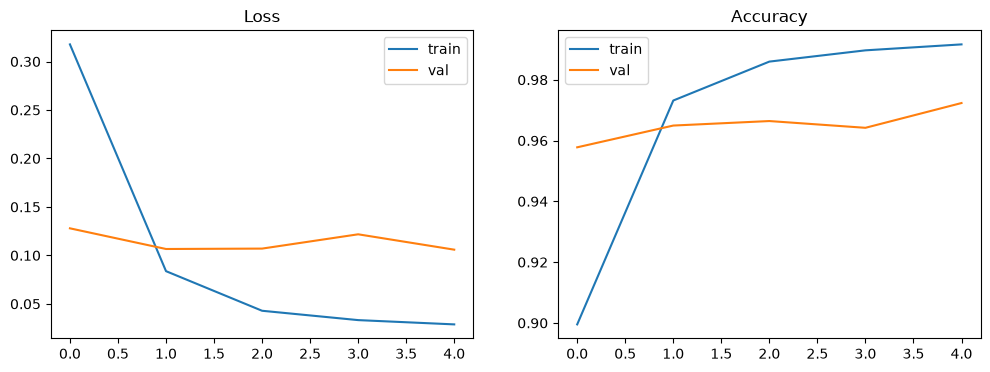

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.show()

## Test set evaluation

                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.96      0.96       472
              Forest       0.99      0.98      0.99       442
HerbaceousVegetation       0.97      0.94      0.95       458
             Highway       0.97      0.95      0.96       391
          Industrial       0.99      0.96      0.98       378
             Pasture       0.94      0.97      0.96       299
       PermanentCrop       0.93      0.96      0.95       379
         Residential       0.97      0.99      0.98       450
               River       0.97      0.98      0.97       375
             SeaLake       0.99      0.99      0.99       406

            accuracy                           0.97      4050
           macro avg       0.97      0.97      0.97      4050
        weighted avg       0.97      0.97      0.97      4050



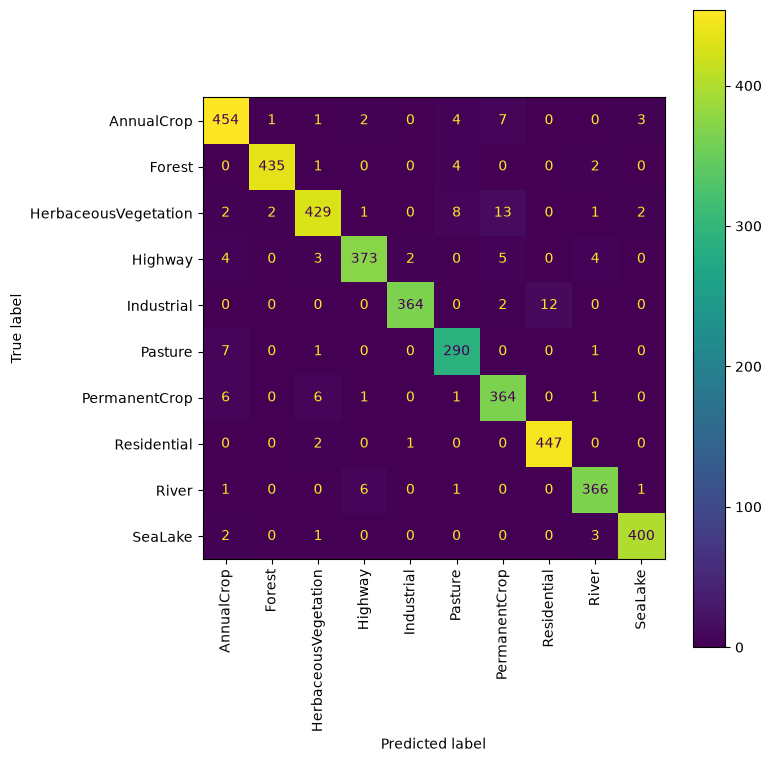

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds, target_names=classes))

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=classes, xticks_rotation="vertical", ax=ax)
plt.tight_layout()
plt.show()

In [11]:
CHECKPOINT_DIR = Path.cwd().parent / "data" / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), CHECKPOINT_DIR / "resnet18_eurosat.pth")
print(f"Saved checkpoint to {CHECKPOINT_DIR / 'resnet18_eurosat.pth'}")

Saved checkpoint to /Users/erizzolio/Work/Alyra/SOLSCAN/data/checkpoints/resnet18_eurosat.pth
